In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from geopy.distance import geodesic
import copy
import itertools
import pandas as pd

In [2]:
ciudades = [
{"nombre": "Ciudad de Mexico", "coords": (19.4326, -99.1332)},
{"nombre": "Nueva York", "coords": (40.7128, -74.0060)},
{"nombre": "Londres", "coords": (51.5074, -0.1278)},
{"nombre": "Tokio", "coords": (35.6762, 139.6503)},
{"nombre": "Sidney", "coords": (-33.8688, 151.2093)},
{"nombre": "Paris", "coords": (48.8566, 2.3522)},
{"nombre": "Berlin", "coords": (52.5200, 13.4050)},
{"nombre": "Roma", "coords": (41.9028, 12.4964)},
{"nombre": "Sao Paulo", "coords": (-23.5505, -46.6333)},
{"nombre": "Buenos Aires", "coords": (-34.6037, -58.3816)},
{"nombre": "El Cairo", "coords": (30.0444, 31.2357)},
{"nombre": "Moscu", "coords": (55.7558, 37.6173)},
{"nombre": "Beijing", "coords": (39.9042, 116.4074)},
{"nombre": "Delhi", "coords": (28.6139, 77.2090)},
{"nombre": "Johannesburgo", "coords": (-26.2041, 28.0473)},
{"nombre": "Toronto", "coords": (43.6532, -79.3832)},
{"nombre": "Dubai", "coords": (25.2769, 55.2962)},
{"nombre": "Singapur", "coords": (1.3521, 103.8198)},
{"nombre": "Estocolmo", "coords": (59.3293, 18.0686)},
{"nombre": "Auckland", "coords": (-36.8485, 174.7633)}
]

In [3]:
def generar_poblacion(tam_poblacion):
    poblacion = []

    for _ in range(tam_poblacion):
        resto = np.random.permutation(range(1, 20))  
        individuo = np.concatenate(([0], resto))
        poblacion.append(individuo)

    return np.array(poblacion)

In [4]:
poblacion = generar_poblacion(100)
poblacion[0]

array([ 0,  5, 11, 13,  1,  7, 16,  3, 10,  4,  6, 17, 14,  8, 19,  2, 12,
        9, 15, 18])

In [5]:
def calcular_matriz_distancias(ciudades):
    n = len(ciudades)
    matriz = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = geodesic(ciudades[i]["coords"], ciudades[j]["coords"]).km
            matriz[i][j] = matriz[j][i] = dist
    return matriz

In [6]:
def fitness_individuo(individuo, matriz_distancia):
    distancia_total = 0
    for i in range(len(individuo) - 1):
        distancia_total += matriz_distancia[individuo[i]][individuo[i+1]]
    # Sumar regreso al inicio (CDMX, índice 0) [cite: 45, 124]
    distancia_total += matriz_distancia[individuo[-1]][individuo[0]]
    return distancia_total

In [7]:
def fitness_tsp(poblacion, matriz_distancias):
    poblacion = np.array(poblacion)
    
    distancias = np.sum(
        matriz_distancias[poblacion[:, :-1], poblacion[:, 1:]],
        axis=1
    )
    
    regreso = matriz_distancias[poblacion[:, -1], poblacion[:, 0]]
    
    return distancias + regreso

In [8]:
individuo = [0, 1]
matriz_distancia = calcular_matriz_distancias(ciudades)

In [9]:
fitness_tsp(poblacion, matriz_distancia)

array([195770.83930209, 181395.89176602, 172816.12330961, 164558.89986544,
       190418.91309017, 180863.92962746, 191439.21495131, 178070.00761719,
       187700.93788824, 168130.2217151 , 179833.32584607, 192037.95699612,
       204607.62013631, 191202.99993292, 192562.57267602, 173510.86903084,
       185914.31229721, 206396.46618669, 170092.99713271, 207555.98559086,
       156471.6971426 , 195393.066145  , 173512.43394986, 193823.86032789,
       194943.5351328 , 183749.1270198 , 202961.51525948, 172123.74028935,
       205082.2673036 , 172322.22125068, 142371.47129703, 179047.24319622,
       150330.98523183, 205034.54250987, 205196.23912731, 216313.69660497,
       182276.80519797, 151445.63404037, 179879.81358776, 145964.58001291,
       192764.78435993, 172409.83954442, 164864.71857708, 192210.64076128,
       183120.19166012, 144311.59874566, 195193.24680404, 197377.72707361,
       198448.13249067, 186047.64111133, 182683.32315743, 171841.83950091,
       194759.90130376, 1

In [10]:
def seleccionar_padres(poblacion, fitness, n_padres=2, n_torneo=5):
    
    indices_torneo = np.random.choice(len(poblacion), size=n_torneo, replace=False)
    
    candidatos = []
    for gen in indices_torneo:
        candidatos.append((poblacion[gen], fitness[gen]))
    
    candidatos_ordenados = sorted(candidatos, key=lambda x: x[1])
    
    ganadores = [c[0] for c in candidatos_ordenados[:n_padres]]
    
    return ganadores

In [11]:
def mutacion_intercambio(individuo, tasa_mutacion):
    if random.random() < tasa_mutacion:
        gen_1, gen_2 = random.sample(range(1, len(individuo)), 2)
        individuo[gen_1], individuo[gen_2] = individuo[gen_2], individuo[gen_1]
        
    return individuo

In [12]:
def mutacion_insercion(individuo, tasa_mutacion):
    if random.random() < tasa_mutacion:
        gen_origen = random.randint(1, len(individuo) - 1)
        gen = individuo.pop(gen_origen)
        
        gen_destino = random.randint(1, len(individuo) - 1)
        individuo.insert(gen_destino, gen)
        
    return individuo

In [13]:
def mutacion_desordenada(individuo, tasa_mutacion):
    individuo = individuo.copy() 
    
    if random.random() < tasa_mutacion:
        size = len(individuo)
        gen_1, gen_2 = sorted(random.sample(range(1, size), 2))

        subsegmento = individuo[gen_1:gen_2+1]
        random.shuffle(subsegmento)
        
        individuo[gen_1:gen_2+1] = subsegmento

    return individuo

In [14]:
def mutacion_inversion(individuo, tasa_mutacion):
    if random.random() < tasa_mutacion:
        size = len(individuo)

        gen_1, gen_2 = sorted(random.sample(range(1, size), 2))
        
        individuo[gen_1:gen_2+1] = individuo[gen_1:gen_2+1][::-1]
        
    return individuo

In [15]:
def cruce_pmx(padre1, padre2):
    hijo1 = padre1.copy()
    hijo2 = padre2.copy()
    
    n = len(padre1)
    punto1 = np.random.randint(1, n - 1)
    punto2 = np.random.randint(punto1 + 1, n)
    
    segmento1 = padre1[punto1:punto2]
    segmento2 = padre2[punto1:punto2]

    hijo1[punto1:punto2] = segmento2
    hijo2[punto1:punto2] = segmento1
    
    def resolver_duplicados(hijo, segmento_propio, segmento_ajeno, p1, p2):
        for i in np.concatenate([np.arange(1, p1), np.arange(p2, n)]):
            candidato = hijo[i]
            while candidato in segmento_ajeno:
                idx_en_ajeno = np.where(segmento_ajeno == candidato)[0][0]
                candidato = segmento_propio[idx_en_ajeno]
            hijo[i] = candidato
        return hijo

    hijo1 = resolver_duplicados(hijo1, segmento1, segmento2, punto1, punto2)
    hijo2 = resolver_duplicados(hijo2, segmento2, segmento1, punto1, punto2)
    
    return hijo1, hijo2

In [16]:
def cruce_orden(p1, p2):
    tamanio = len(p1)
    h1, h2 = [None]*tamanio, [None]*tamanio
    
    h1[0], h2[0] = 0, 0
    
    cruce_1, cruce_2 = sorted(random.sample(range(1, tamanio), 2))
    
    h1[cruce_1:cruce_2+1] = p1[cruce_1:cruce_2+1]
    h2[cruce_1:cruce_2+1] = p2[cruce_1:cruce_2+1]
    
    def rellenar_orden(hijo, padre, corte2):
        size = len(padre)
        pos_hijo = (corte2 + 1) % size
        pos_padre = (corte2 + 1) % size
        
        while None in hijo:
            if pos_hijo == 0:
                pos_hijo = 1
                continue
            
            ciudad_candidata = padre[pos_padre % size]
            if ciudad_candidata not in hijo:
                hijo[pos_hijo] = ciudad_candidata
                pos_hijo = (pos_hijo + 1) % size
            pos_padre = (pos_padre + 1) % size

    rellenar_orden(h1, p2, cruce_2)
    rellenar_orden(h2, p1, cruce_2)
    return h1, h2

In [17]:

def cruce_ciclos(p1, p2):
    tamanio = len(p1)
    h1, h2 = [None]*tamanio, [None]*tamanio
    
    h1[0], h2[0] = 0, 0

    def resolver_ciclo(hijo, p_donante, p_otro):
        try:
            inicio = next(i for i, v in enumerate(hijo) if v is None)
        except StopIteration:
            return 
            
        current = inicio
        while hijo[current] is None:
            hijo[current] = p_donante[current]
            valor_buscado = p_otro[current]
            mapa = {v: i for i, v in enumerate(p_donante)}
            current = mapa[valor_buscado]

    turno_p1 = True
    while None in h1:
        if turno_p1:
            resolver_ciclo(h1, p1, p2)
            resolver_ciclo(h2, p2, p1)
        else:
            resolver_ciclo(h1, p2, p1)
            resolver_ciclo(h2, p1, p2)
        turno_p1 = not turno_p1
        
    return h1, h2

In [18]:
def cruce_bordes(p1, p2):
    size = len(p1)
    
    adj = {i: set() for i in p1} 
    for p in [p1, p2]:
        for i in range(size):
            v1 = p[(i - 1) % size]
            v2 = p[(i + 1) % size]
            adj[p[i]].add(v1)
            adj[p[i]].add(v2)
    
    def generar_hijo(adj_copy):
        hijo = []
        current = 0
        
        while len(hijo) < size:
            hijo.append(current)
            
            for v in adj_copy:
                adj_copy[v].discard(current)
            
            if len(hijo) == size:
                break
            
            vecinos = list(adj_copy[current])
            
            if vecinos:
                min_grado = min(len(adj_copy[v]) for v in vecinos)
                candidatos = [v for v in vecinos if len(adj_copy[v]) == min_grado]
                current = random.choice(candidatos)  # 🔥 clave
            else:
                restantes = [n for n in adj_copy.keys() if n not in hijo]
                current = random.choice(restantes)
                
        return hijo

    h1 = generar_hijo(copy.deepcopy(adj))
    h2 = generar_hijo(copy.deepcopy(adj))
    
    return h1, h2

In [19]:
p1 = [0, 1, 2, 3, 4, 5, 6, 7, 8]
p2 = [3, 5, 1, 8, 0, 2, 7, 6, 4]
h1, h2 = cruce_ciclos(p1, p2)
print(h1)
print(h2)

[0, 1, 2, 8, 4, 5, 7, 6, 8]
[0, 5, 1, 3, 4, 2, 7, 6, 8]


In [20]:
mutacion_desordenada(h1, 0.5)

[0, 1, 2, 8, 7, 5, 4, 6, 8]

In [21]:
def seleccion_supervivientes(poblacion_actual, hijos, fitness_actual, elitismo=True):
    tam_poblacion = len(poblacion_actual)
    
    hijos = np.array(hijos) 
    
    if not elitismo:
        return hijos[:tam_poblacion]
    
    n_elite = max(1, int(tam_poblacion * 0.05))
    
    idx_elite = np.argpartition(fitness_actual, n_elite)[:n_elite]
    elites = poblacion_actual[idx_elite]
    
    n_hijos_necesarios = tam_poblacion - n_elite
    idx = np.random.choice(len(hijos), n_hijos_necesarios, replace=False)
    hijos_seleccionados = hijos[idx]
    
    nueva_poblacion = np.vstack((elites, hijos_seleccionados))
    
    return nueva_poblacion

In [22]:
def obtener_aristas(ruta):
    aristas = set()
    n = len(ruta)
    for i in range(n):
        u = ruta[i]
        v = ruta[(i + 1) % n]
        if u < v:
            aristas.add((u, v))
        else:
            aristas.add((v, u))
    return aristas


def calcular_diversidad(poblacion, muestras=200):
    n_pob = len(poblacion)
    n_ciudades = len(poblacion[0])
    
    aristas_pob = [obtener_aristas(ind) for ind in poblacion]
    
    distancias = []
    
    for _ in range(muestras):
        i, j = random.sample(range(n_pob), 2)
        comunes = len(aristas_pob[i].intersection(aristas_pob[j]))
        dist_ij = 1 - (comunes / n_ciudades)
        distancias.append(dist_ij)
        
    return np.mean(distancias)

In [23]:
SEED = 64

np.random.seed(SEED)
random.seed(SEED)

matriz_distancia = calcular_matriz_distancias(ciudades)
def algoritmo_genetico(metodo_cruza, metodo_mutacion, con_elitismo, tasa_mutacion, tamano_poblacion, matriz_distancia, max_generaciones=30): 
    historial = {'min': [], 'max': [], 'mean': [], 'div': []}

    poblacion = generar_poblacion(tamano_poblacion) 

    for generacion in range(max_generaciones):
        # 1. Evaluación 

        aptitudes = fitness_tsp(poblacion, matriz_distancia)

        # 2. Registro de estadísticas 
        historial['min'].append(np.min(aptitudes))
        historial['max'].append(np.max(aptitudes))
        historial['mean'].append(np.mean(aptitudes))
        historial['div'].append(calcular_diversidad(poblacion))

        # 3. Construcción de la nueva generación
        hijos = []
        
        # Generamos suficientes hijos para llenar la población
        for _ in range(tamano_poblacion // 2):
            padres = seleccionar_padres(poblacion, aptitudes)
            
            h1, h2 = metodo_cruza(list(padres[0]), list(padres[1]))

            h1 = list(h1)
            h2 = list(h2)

            h1 = metodo_mutacion(h1, tasa_mutacion)
            h2 = metodo_mutacion(h2, tasa_mutacion)

            h1 = np.array(h1)
            h2 = np.array(h2)

            hijos.extend([h1, h2])

        poblacion = seleccion_supervivientes(poblacion, hijos, aptitudes, con_elitismo)

    aptitudes_finales = fitness_tsp(poblacion, matriz_distancia)
    
    mejor_idx = np.argmin(aptitudes_finales) 
    mejor_individuo = poblacion[mejor_idx]

    print(f"Mejor Distancia Final: {aptitudes_finales[mejor_idx]} km")

    return mejor_individuo, historial

In [24]:
def graficar_fitness(historial):

    plt.plot(historial['min'], label="Fitness mínimo")
    plt.plot(historial['mean'], label="Fitness promedio")
    plt.plot(historial['max'], label="Fitness máximo")

    plt.xlabel("Generación")
    plt.ylabel("Fitness")
    plt.title("Evolución del fitness")
    plt.legend()

    plt.show()

In [25]:
def graficar_diversidad_genetica(historial):
    plt.plot(historial['div'])

    plt.xlabel("Generación")
    plt.ylabel("Diversidad genética")
    plt.title("Evolución de la diversidad")

    plt.show()

In [26]:
def mostrar_individuo(individuo):
    datos_individuo = []
    for gen in individuo:
        datos_individuo.append(ciudades[gen].get("nombre"))

    return datos_individuo

In [27]:
def dibuja_ruta(individuo, ciudades):
    ruta_coords = [ciudades[i]["coords"] for i in individuo]
    ruta_coords.append(ciudades[individuo[0]]["coords"]) # Cerrar el ciclo
    latitud, longitud = zip(*ruta_coords)
    plt.figure(figsize=(9, 5))
    plt.plot(longitud, latitud, linestyle='-', color='gray')
    
    # Dibuja todas las ciudades
    for i in range(len(ciudades)):
        lat, long = ciudades[i]["coords"]
        plt.scatter(long, lat, color='blue')
        plt.text( long+2, lat, ciudades[i]['nombre'], fontsize=8)

    #Dibuja el punto inicial
    print(ciudades[individuo[0]]["nombre"])
    print(ciudades[individuo[0]]["coords"])
    lat, long = ciudades[individuo[0]]["coords"]
    plt.scatter(long, lat, color='orange')

    #Grafica el ´ındice de la ciudad
    for i, (lat, long) in enumerate(ruta_coords[:-1]):
        plt.text(long-5, lat, str(individuo[i]), fontsize=8)

    plt.title(f"Ruta del Agente Viajero (Distancia: {fitness_individuo(individuo, matriz_distancia=calcular_matriz_distancias(ciudades))})")
    plt.show()


In [58]:
matriz_distancia = calcular_matriz_distancias(ciudades)
individuo, historial = algoritmo_genetico(metodo_cruza=cruce_orden, metodo_mutacion=mutacion_desordenada, con_elitismo=False, tasa_mutacion= 0.20, tamano_poblacion= 100, matriz_distancia=matriz_distancia, max_generaciones=200)

Mejor Distancia Final: 88460.38216239538 km


In [29]:
historial['div'][199]

np.float64(0.06475)

In [30]:
individuo

array([ 0, 18, 11,  6,  7, 10, 16, 13, 12,  3, 19,  4, 17, 14,  9,  8,  5,
        2,  1, 15])

In [31]:
mostrar_individuo(individuo)


['Ciudad de Mexico',
 'Estocolmo',
 'Moscu',
 'Berlin',
 'Roma',
 'El Cairo',
 'Dubai',
 'Delhi',
 'Beijing',
 'Tokio',
 'Auckland',
 'Sidney',
 'Singapur',
 'Johannesburgo',
 'Buenos Aires',
 'Sao Paulo',
 'Paris',
 'Londres',
 'Nueva York',
 'Toronto']

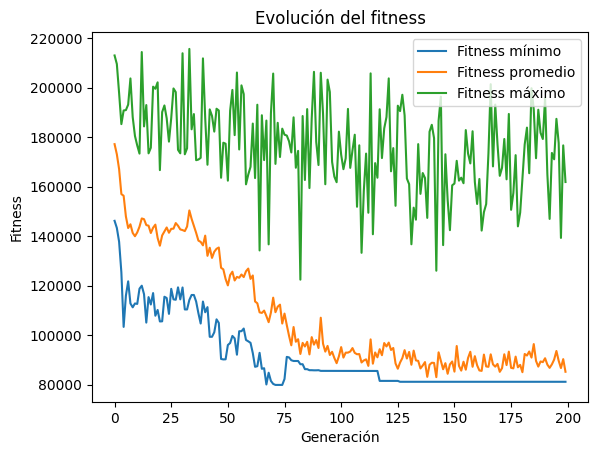

In [32]:
graficar_fitness(historial)

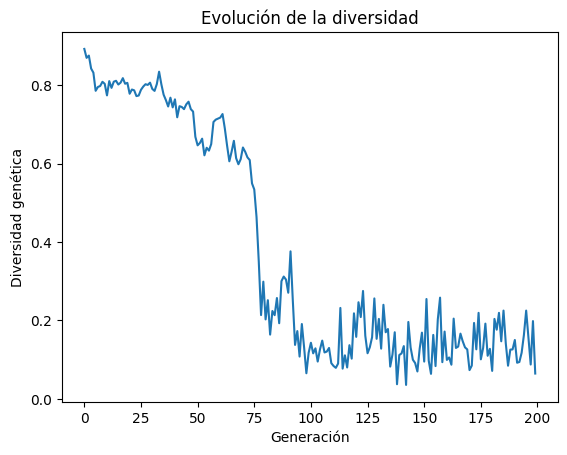

In [33]:
graficar_diversidad_genetica(historial)

Ciudad de Mexico
(19.4326, -99.1332)


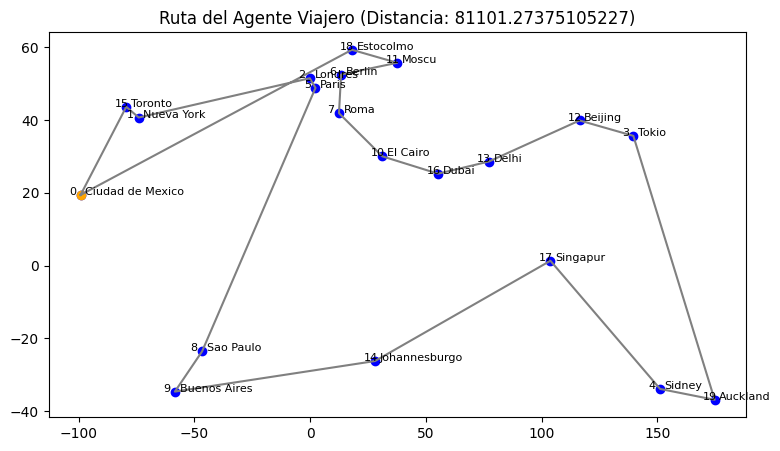

In [34]:
dibuja_ruta(individuo, ciudades)

In [35]:
configuraciones = {
    'cruza': [cruce_pmx, cruce_bordes, cruce_ciclos, cruce_orden],
    'mutacion': [mutacion_intercambio],
    'elitismo': [True, False],
    'tasa_mutacion': [0.05],
    'tam_poblacion': [100]
}

In [36]:
# import itertools
# import pandas as pd

# resultados_totales = []

# combinaciones = list(itertools.product(
#     configuraciones['cruza'], 
#     configuraciones['mutacion'], 
#     configuraciones['elitismo'],
#     configuraciones['tasa_mutacion'],
#     configuraciones['tam_poblacion']
# ))

# print(f"Iniciando experimentos. Total configuraciones: {len(combinaciones)}")

# N_EJECUCIONES = 30
# matriz_distancia = calcular_matriz_distancias(ciudades)
# for cruza, mutacion, elitismo, tasa_mutacion, tam_poblacion in combinaciones:
    
#     nombre_config = f"{cruza.__name__} | {mutacion.__name__} | mut:{tasa_mutacion} | pob:{tam_poblacion} | elit:{elitismo}"
#     print(f"\nEjecutando: {nombre_config}")
    
#     for ejecucion in range(N_EJECUCIONES):
        
#         mejor_ind, historial = algoritmo_genetico(
#         cruza, mutacion, elitismo, tasa_mutacion, tam_poblacion, matriz_distancia, max_generaciones=200
#         )   
    
#         mejor_fitness = historial['min'][-1]
        
#         resultados_totales.append({
#             'Configuracion': nombre_config,
#             'Cruza': cruza.__name__,
#             'Mutacion': mutacion.__name__,
#             'Tasa_mutacion': tasa_mutacion,
#             'Tam_poblacion': tam_poblacion,
#             'Ejecución No.': ejecucion, 
#             'Elitismo': elitismo,
#             'Mejor_Fitness': mejor_fitness,
#             'Diversidad_Final': historial['div'][-1],
#         })


# # DataFrame
# df_resultados = pd.DataFrame(resultados_totales)

# # Guardar CSV
# df_resultados.to_csv('resultados_tsp.csv', index=False)

# print("Experimentos completados")